<a href="https://colab.research.google.com/github/amigli/Q-Bert_RL/blob/main/Notebook/SARSA_lambda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training e Test con SARSA(λ)
In questo notebook è presente il training di Q*Bert sfruttando l'algoritmo SARSA(λ)

## Download Repository

Download della repository per utilizzare le classi create su Google Colab

In [1]:
from google.colab import userdata

In [2]:
! git clone https://{userdata.get('TokenGithub')}"@github.com/amigli/Q-Bert_RL.git"

Cloning into 'Q-Bert_RL'...
remote: Enumerating objects: 586, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 586 (delta 33), reused 28 (delta 19), pack-reused 528 (from 1)
Receiving objects: 100% (586/586), 10.00 MiB | 20.16 MiB/s, done.
Resolving deltas: 100% (370/370), done.


In [3]:
%cd Q-Bert_RL

/content/Q-Bert_RL


## Installazione dei requirements

Vengono installati tutti i moduli necessari dal file requirements.txt

In [4]:
!pip install gymnasium

In [5]:
!pip install ale-py

In [6]:
!pip install moviepy

## Salvataggio statistiche
Predisposizione delle cartelle su Drive per il salvataggio delle statistiche di training

In [7]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
dir = '/content/drive/MyDrive/Q-Bert_RL/SARSA_Lambda/'

In [9]:
import os

if not(os.path.exists(dir)):
  os.mkdir(dir)

In [10]:
import datetime
dir = dir + "Training_" + str(datetime.datetime.now())

if not(os.path.exists(dir)):
  os.mkdir(dir)

## Training

In [11]:
from Algorithms.QBertAgent_SARSA_lambda import SARSALambdaAgent
import gymnasium as gym
import ale_py
from tqdm.notebook import tqdm, trange
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
from EnvironmentWrappers.ObsRewardWrapper import ObsRewardWrapper
from EnvironmentWrappers.utils  import salva_csv

gym.register_envs(ale_py)

# hyperparameters
step_size = 0.01
n_episodes = 350
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

## TRAINING
env = gym.make("ALE/Qbert-ram-v5")
env =  ObsRewardWrapper(env)
env = RecordEpisodeStatistics(env, buffer_length=n_episodes)

reward_per_episode = []
step_per_episode = []
epsilon_value = []

agent = SARSALambdaAgent(
    env=env,
    step_size=step_size,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

last_reward = 0

for episode in trange(n_episodes, desc="Training Progress"):
    obs, info = env.reset()
    done = False
    obs = tuple(obs)
    # print("Episode:" + str(episode))
    total_reward = 0
    total_step = 0
    action = agent.get_action(obs, True)

    while not done:
        # print(action)
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_obs = tuple(next_obs)
        # print("Reward: " + str(reward))
        # print("action: " + str(action))
        next_action = agent.get_action(next_obs, True)
        total_reward += reward
        total_step +=1

        # update the agent
        agent.update(obs, action, reward, terminated, next_obs, next_action)

        done = terminated or truncated
        obs = next_obs
        action = next_action

    if total_reward > last_reward:
      tqdm.write(f"New Best Reward:{total_reward}")
      last_reward = total_reward

    reward_per_episode.append(total_reward)
    step_per_episode.append(total_step)
    epsilon_value.append(agent.epsilon)
    agent.decay_epsilon()
    # print(total_reward)

env.close()

Training Progress:   0%|          | 0/350 [00:00<?, ?it/s]

New Best Reward:2
New Best Reward:7
New Best Reward:11
New Best Reward:11.5
New Best Reward:12


Salvataggio delle statistiche

In [13]:
salva_csv(reward_per_episode, "Reward",dir + "/csv_reward.csv")
salva_csv(step_per_episode, "Steps", dir + "/csv_steps.csv")
salva_csv(epsilon_value, "Epsilon", dir +"/csv_epsilon.csv")

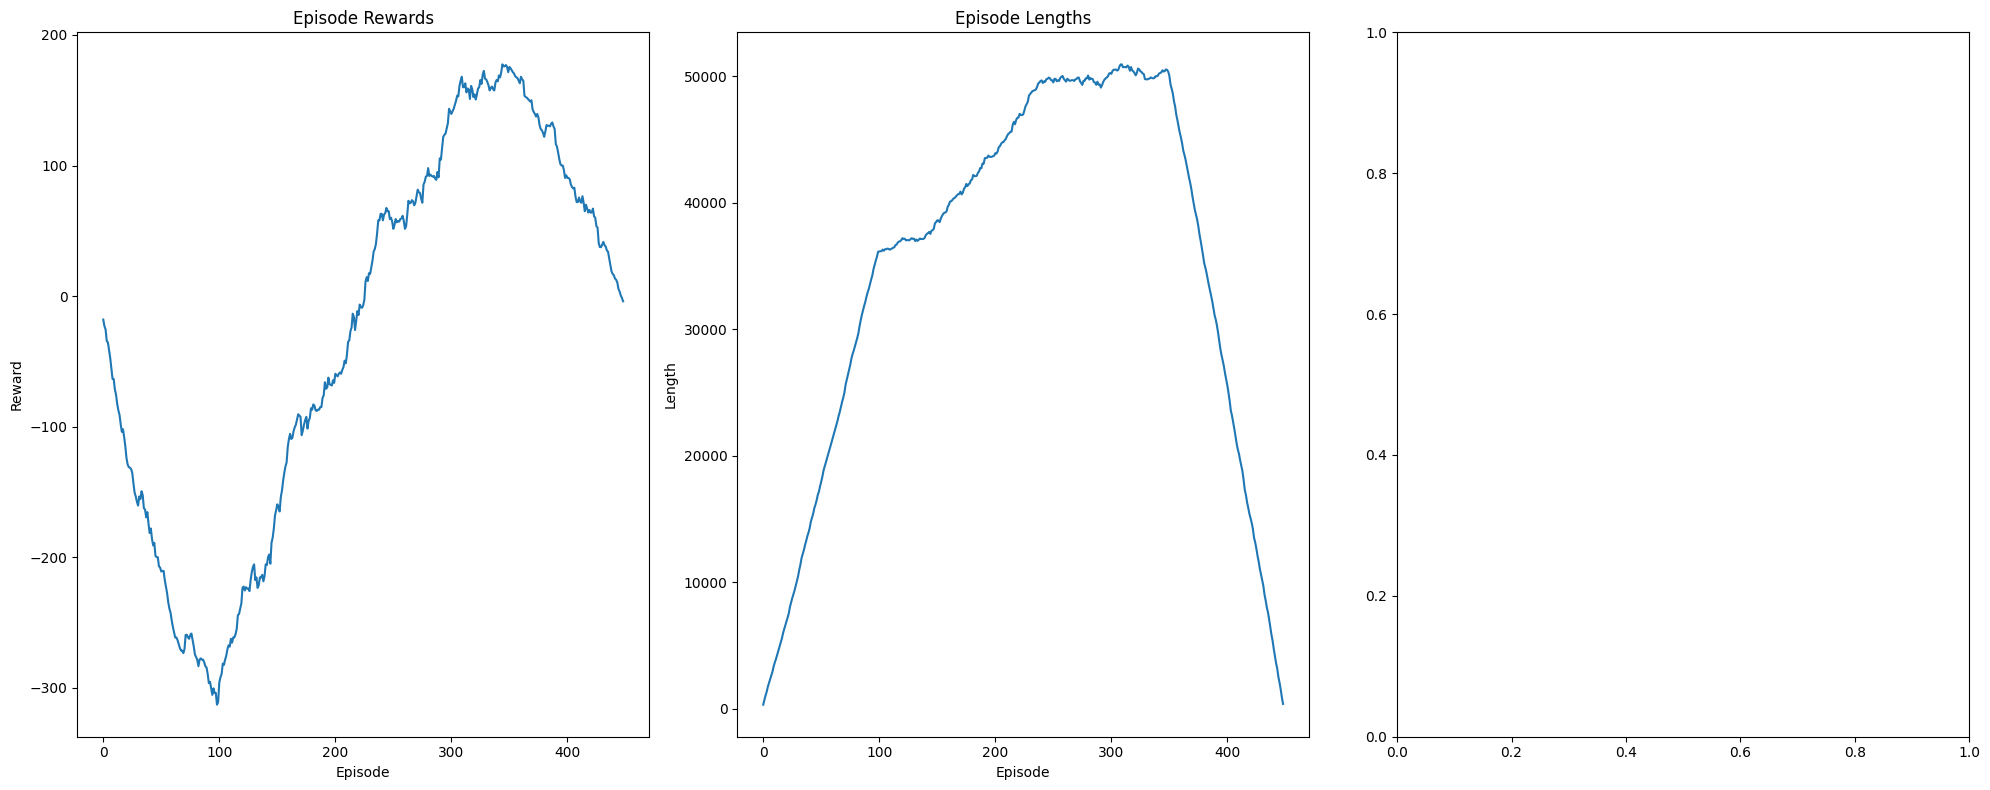

In [14]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

#axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
#axs[2].set_title("Training Error")
#axs[2].set_xlabel("Episode")
#axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

# Utilizzo Policy

Di seguito viente utilizzata la policy precedentemente calcolata per registrare degli episodi

In [15]:
num_eval_episodes = 10

env = gym.make("ALE/Qbert-ram-v5", render_mode="rgb_array")
env =  ObsRewardWrapper(env)
env = RecordVideo(env, video_folder="videos_first", name_prefix="eval",
                  episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)


for episode_num in range(num_eval_episodes):
    #print(f"Stato osservato: {obs}")  # Debug per lo stato osservato
    #print(f"Valori Q per lo stato {obs}: {agent.q_values[obs]}")  # Debug per i valori Q
    obs, info = env.reset()
    done = False
    obs = tuple(obs)
    while not done:
        action = agent.get_action(obs, False)
        next_obs, reward, terminated, truncated, info = env.step(action)
        obs = tuple(next_obs)
        done = terminated or truncated
env.close()

print(f'Episode time taken: {env.time_queue}')
print(f'Episode total rewards: {env.return_queue}')
print(f'Episode lengths: {env.length_queue}')

print("Training terminato")

Episode time taken: deque([0.443358, 0.431017, 0.38088, 0.44232, 0.435989, 0.378197, 0.430214, 0.444167, 0.56136, 0.460527], maxlen=10)
Episode total rewards: deque([-14.0, 1.0, -6.0, -5.0, 1.0, 0.0, 1.0, 1.0, 0.5, -5.0], maxlen=10)
Episode lengths: deque([691, 691, 593, 713, 691, 600, 691, 691, 908, 713], maxlen=10)
Training terminato


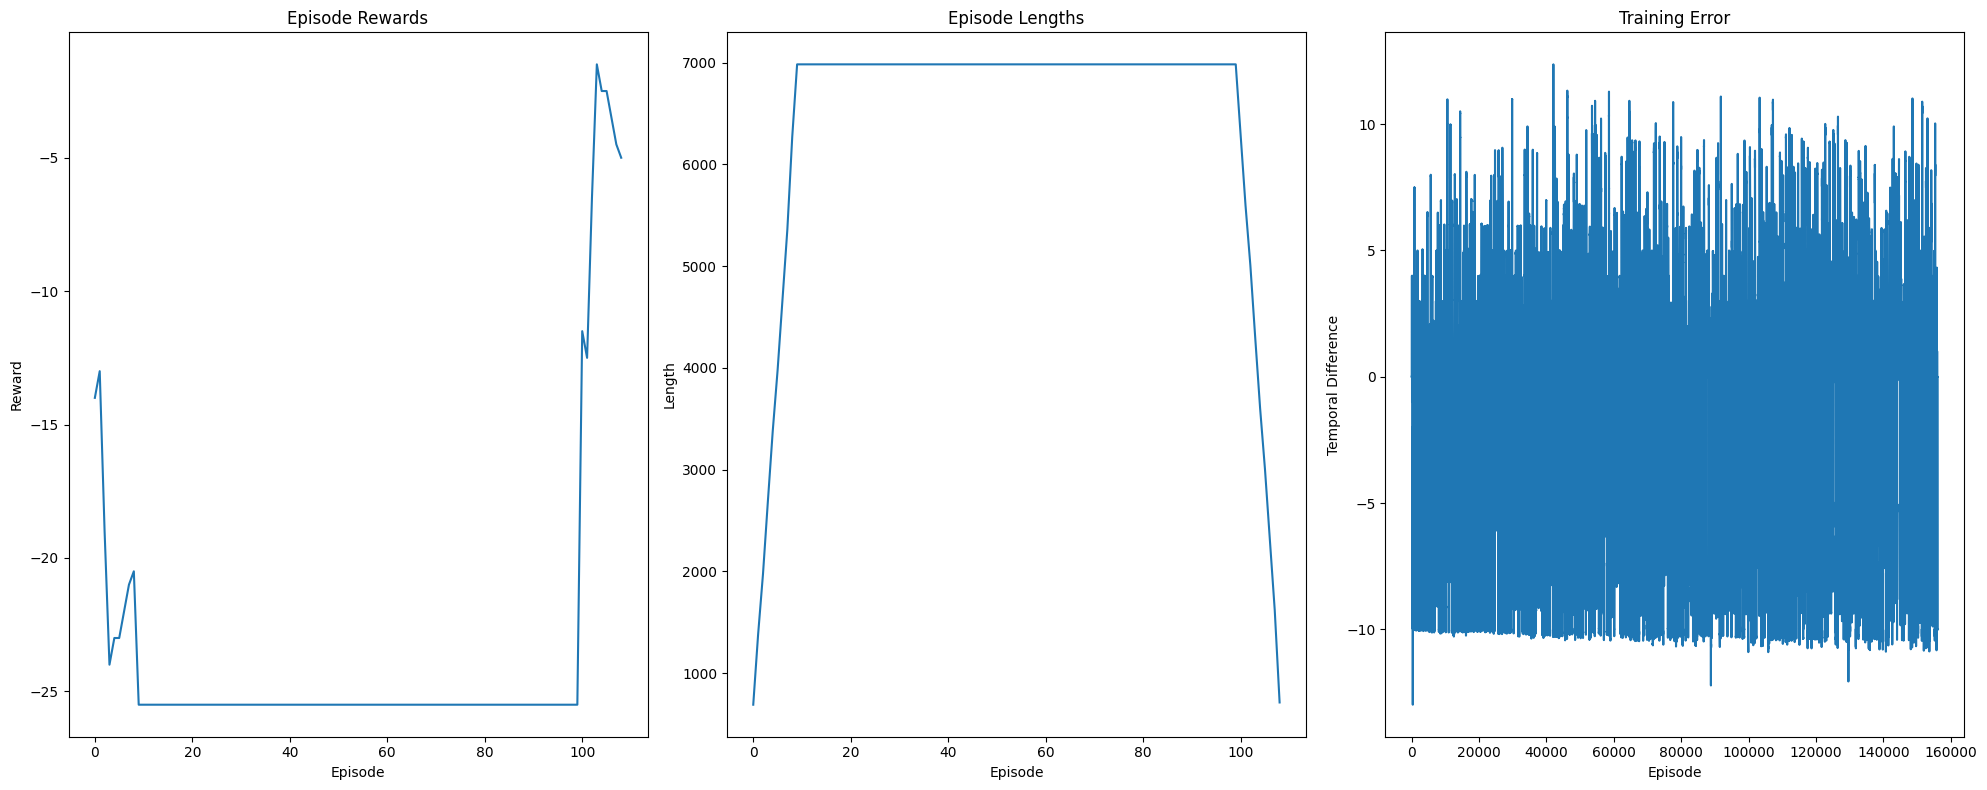

In [16]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
axs[2].set_title("Training Error")
axs[2].set_xlabel("Episode")
axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

In [17]:
import shutil

dir_video =  dir + "/video/"
if not os.path.exists(dir_video):
  os.makedirs(dir_video)

source_video = "/content/Q-Bert_RL/videos_first/"

for file_name in os.listdir(source_video):
   source_path = os.path.join(source_video, file_name)
   destination_path = os.path.join(dir_video, file_name)

   if os.path.isfile(source_path):
      shutil.copy2(source_path, destination_path)
      print(f"Copiato: {file_name}")

Copiato: eval-episode-2.mp4
Copiato: eval-episode-6.mp4
Copiato: eval-episode-4.mp4
Copiato: eval-episode-8.mp4
Copiato: eval-episode-5.mp4
Copiato: eval-episode-7.mp4
Copiato: eval-episode-9.mp4
Copiato: eval-episode-3.mp4
Copiato: eval-episode-0.mp4
Copiato: eval-episode-1.mp4


In [18]:
agent.save_q_values()